<a href="https://colab.research.google.com/github/bforoura/GENAI26/blob/main/Module5/Plan_and_Execute_Agent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Plan-and-Execute Agent**

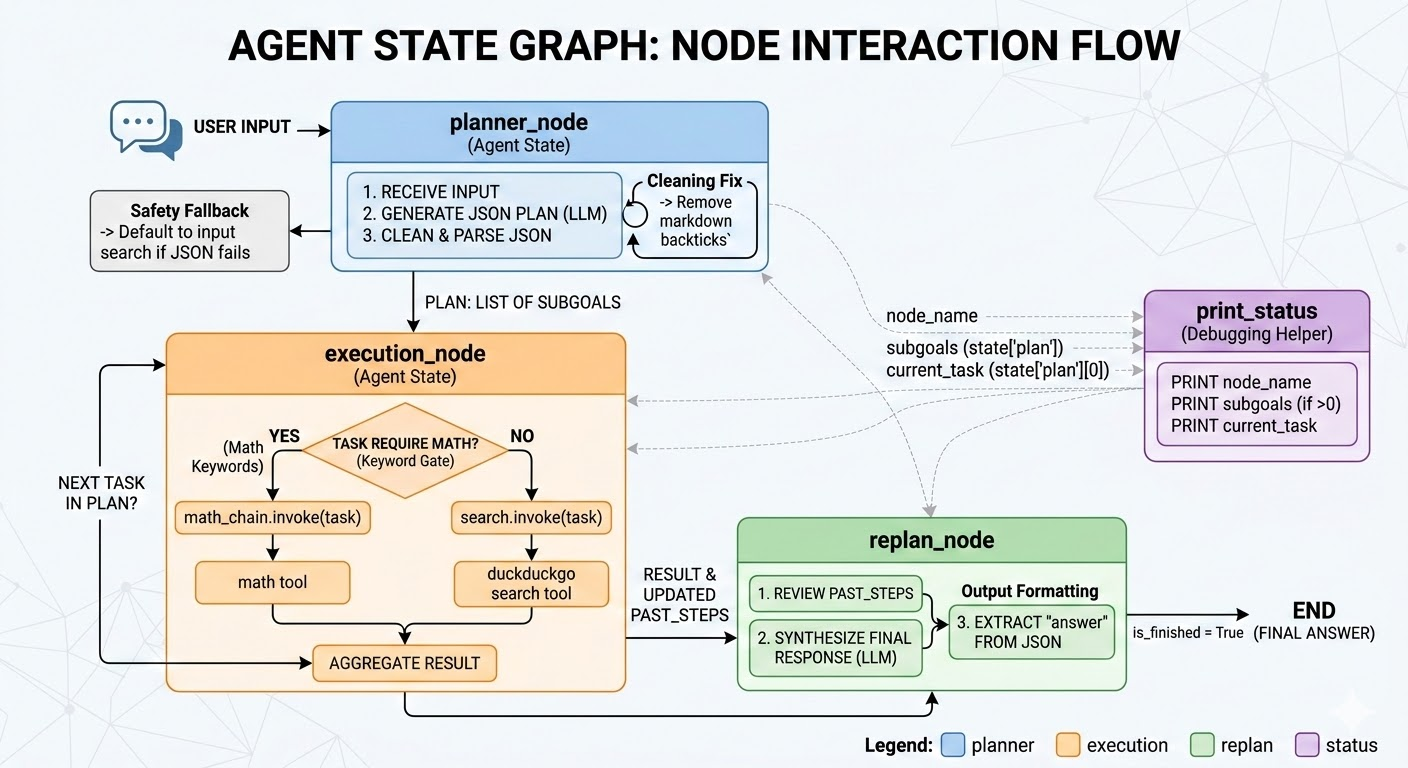

In [ ]:
!apt-get install -y graphviz libgraphviz-dev pkg-config
!pip install -qU langgraph langchain-google-genai langchain-community langchain-classic duckduckgo-search numexpr ddgs



In [ ]:
import os
import operator
import json
import hashlib
from typing import Annotated, List, Tuple, TypedDict, Literal
from google.colab import userdata
from IPython.display import Image, display
from langchain_core.rate_limiters import InMemoryRateLimiter

from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_community.tools import DuckDuckGoSearchRun
from langchain_classic.chains import LLMMathChain
from langchain_core.messages import HumanMessage, SystemMessage
from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, START, END



In [ ]:
os.environ["GOOGLE_API_KEY"] = userdata.get('GOOGLE_API_KEY')

# This ensures you don't burn through your RPM too fast.
rate_limiter = InMemoryRateLimiter(
    requests_per_second=0.1,
    check_every_n_seconds=0.1,
    max_bucket_size=10
)


# The llm is initialized with a specific response_mime_type to encourage consistent JSON output from the model.
llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash-lite",
    temperature=0.1,
    rate_limiter=rate_limiter,
    model_kwargs={"response_mime_type": "application/json"}
)

# TOOLS
search = DuckDuckGoSearchRun()

math_chain = LLMMathChain.from_llm(llm=llm)


# **Agent State**

* This acts as the **shared memory** for the agent.

* It tracks the original user **input**, the current **plan** (list of **subgoals**), the **history** of search results (**past_steps**), and the final synthesized **response**.

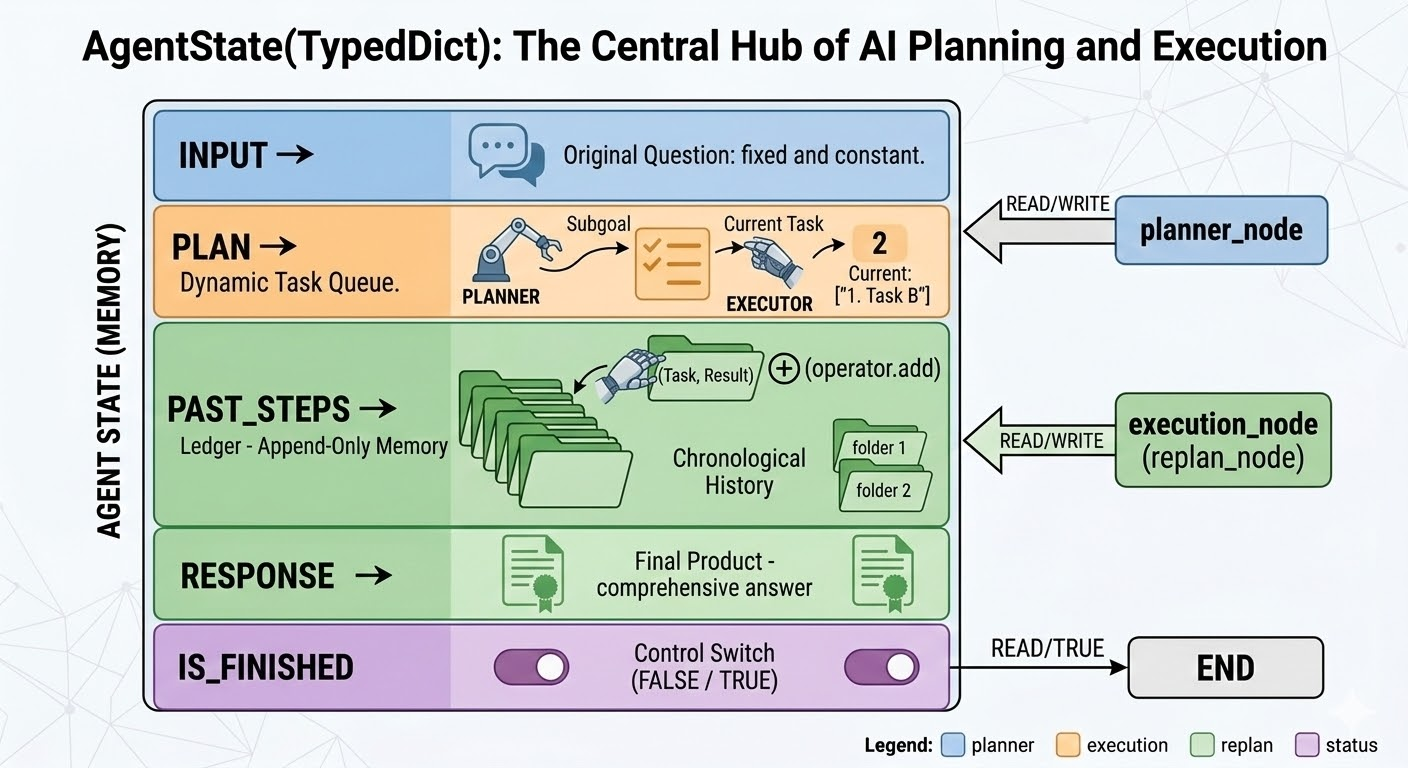

In [ ]:
# STATE

class AgentState(TypedDict):
    input: str
    plan: List[str]
    past_steps: Annotated[List[Tuple], operator.add]
    response: str
    is_finished: bool




# **The "Brains" of the Agent**

Each **node** (**function**) represents a specific stage in the thinking process, and the routing logic determines the flow between them.

---
**print_status**

  * This is a helper function used for debugging and transparency.
  * It gives you a "**peek**" into the agent's brain while it's running.
  * It prints the current node name, how many sub-goals are left in the queue, and exactly what the agent is doing at that moment.
  * Without this, the agent would feel like a "black box" until the final answer appeared.
---
**planner_node**

* This is the **Architect**.
* It takes the **big question** and **breaks it into smaller**, actionable pieces.
* It asks the LLM to return a JSON list of "**steps**"

* LLMs often wrap JSON in triple backticks (json ... ). This code manually strips those away so json.loads() doesn't crash.

* If the LLM provides a bad format or the code fails to parse the JSON, it doesn't stop. It simply defaults the "**plan**" to be a single search for your original question.

---
**execution_node**

* This is the **Worker**. It performs the actual research or math.

* It takes the first item from the plan list and executes it.

* It uses a "**keyword gate:**" if it sees words like "**calculate**" or "**math**," it sends the task to the **math_chain**. Otherwise, it uses the **DuckDuckGo** search tool.

* Once the task is done, it removes that task from the plan and saves the result into **past_steps**, i.e, the **agent's memory**.

---
**replan_node**

* This is the **Editor/Synthesizer**: it reviews the work once the plan is empty.

* If there are no more steps in the plan, it triggers the "**final answer**" logic.

* It hands all the facts gathered in past_steps back to the **LLM** and asks it to **write a comprehensive response based only on those facts**.

* Like the planner, it tries to extract the final answer from a JSON structure to keep the output clean.

---
**should_continue (The Router)**

* This is the **Traffic Controller**.

* It looks at the **is_finished** flag in the state.

* If **is_finished** is True, it sends the agent to **END**.

* If **False**, it sends the agent back to the executor to handle the next task in the plan. This is what creates the "**looping**" behavior of the agent.



In [ ]:
#  NODES

###############################################################################
def print_status(node_name: str, subgoals: List[str], current_task: str = None):
    print(f"\n--- [NODE]: {node_name} ---")
    if subgoals:
        print(f"Subgoals remaining: {subgoals}")
    if current_task:
        print(f"Executing: {current_task}")



###############################################################################
def planner_node(state: AgentState):
    print("\n[PLANNER]: Analyzing request and mapping subgoals...")
    prompt = f"""Break down this request into 2 search steps: {state['input']}
    Return ONLY JSON: {{"steps": ["step 1", "step 2"]}}"""

    output = llm.invoke(prompt)

    # --- CHANGE STARTS HERE ---
    content = output.content.strip()
    if content.startswith("```"):
        # Strip triple backticks and 'json' identifier if present
        content = content.replace("```json", "").replace("```", "").strip()
    # --- CHANGE ENDS HERE ---

    try:
        plan_data = json.loads(content)
        steps = plan_data.get("steps", [])
        print_status("planner", steps)
        return {"plan": steps, "is_finished": False}
    except Exception as e:
        print(f"[PLANNER ERROR]: {e}. Falling back to dynamic search.")
        return {"plan": [state['input']], "is_finished": False}


###############################################################################
def execution_node(state: AgentState):
    if not state["plan"]:
        return {"is_finished": True}

    task = state["plan"][0]
    print_status("executor", state["plan"][1:], current_task=task)

    # IMPROVED LOGIC: Only use math tool if the task specifically asks for a calculation
    # "Compare" or "Research" should always go to Search.
    math_keywords = ["calculate", "solve", "math", "total sum of", "equation"]
    if any(m in task.lower() for m in math_keywords):
        try:
            result = math_chain.invoke(task)["answer"]
        except Exception as e:
            result = f"Math tool failed: {str(e)}. Falling back to search."
            result += " " + search.invoke(task)
    else:
        result = search.invoke(task)

    return {"past_steps": [(task, result)], "plan": state["plan"][1:]}



###############################################################################
def replan_node(state: AgentState):
    if not state["plan"]:
        print_status("replan", [], "Synthesizing final answer")

        summary_prompt = (
            f"Given these facts: {state['past_steps']}\n"
            f"Answer the user query: {state['input']}\n\n"
            f"Return ONLY JSON with the format: {{" + '"answer": "your comprehensive response"' + "}"
        )

        summary = llm.invoke(summary_prompt)
        try:
            res = json.loads(summary.content).get("answer", summary.content)
            return {"response": res, "is_finished": True}
        except:
            # Clean up potential markdown formatting if JSON parsing fails
            clean_res = summary.content.replace("```json", "").replace("```", "").strip()
            return {"response": clean_res, "is_finished": True}

    return {"is_finished": False}



###############################################################################
def should_continue(state: AgentState) -> Literal["executor", "__end__"]:
    return END if state.get("is_finished") else "executor"



###############################################################################
# GRAPH CONSTRUCTION
###############################################################################
workflow = StateGraph(AgentState)

workflow.add_node("planner", planner_node)
workflow.add_node("executor", execution_node)
workflow.add_node("replan", replan_node)

workflow.add_edge(START, "planner")
workflow.add_edge("planner", "executor")
workflow.add_edge("executor", "replan")
workflow.add_conditional_edges("replan", should_continue, {"executor": "executor", END: END})

app = workflow.compile()




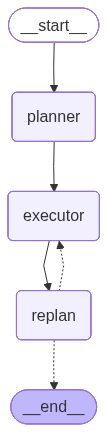

In [ ]:
# The state graph

try:
    from IPython.display import Image, display
    # Generate the Mermaid diagram and display it as a PNG
    display(Image(app.get_graph().draw_mermaid_png()))

except Exception as e:
    # Fallback if the necessary system libraries are missing
    print(f"Could not render graph: {e}")


In [ ]:
# Used for session management
import uuid

###############################################################################
query = "How far is Philadelphia from New York City?"

config = {"configurable": {"thread_id": str(uuid.uuid4())}}
inputs = {"input": query, "plan": [], "past_steps": [], "is_finished": False}

print("--- STARTING DYNAMIC AGENT ---")
for event in app.stream(inputs, config=config, stream_mode="updates"):
    for node, value in event.items():
        if "response" in value:
            print(f"\n--- FINAL ANSWER ---\n{value['response']}")



--- STARTING DYNAMIC AGENT ---

[PLANNER]: Analyzing request and mapping subgoals...

--- [NODE]: planner ---
Subgoals remaining: ['distance between Philadelphia and New York City', 'driving distance from Philadelphia to New York City']

--- [NODE]: executor ---
Subgoals remaining: ['driving distance from Philadelphia to New York City']
Executing: distance between Philadelphia and New York City

--- [NODE]: executor ---
Executing: driving distance from Philadelphia to New York City

--- [NODE]: replan ---
Executing: Synthesizing final answer

--- FINAL ANSWER ---
The distance between Philadelphia and New York City is approximately 80 to 95 miles (125-153 kilometers) as the crow flies. The driving distance is generally around 95 miles, taking about 2 to 2.5 hours by car under normal conditions.


In [ ]:
import uuid

###############################################################################
query = "What is the best way to travel from Philadelphia to New York City?"

config = {"configurable": {"thread_id": str(uuid.uuid4())}}
inputs = {"input": query, "plan": [], "past_steps": [], "is_finished": False}

print("--- STARTING DYNAMIC AGENT ---")
for event in app.stream(inputs, config=config, stream_mode="updates"):
    for node, value in event.items():
        if "response" in value:
            print("\n--- FINAL ANSWER ---")
            raw_response = value['response']

            # THE FIX: Post-processing the response to remove JSON brackets
            try:
                # Attempt to parse as JSON and extract the 'answer' field
                parsed = json.loads(raw_response)
                clean_text = parsed.get("answer", raw_response)
                print(clean_text)
            except:
                # If it's not valid JSON, just print it as-is
                print(raw_response)



--- STARTING DYNAMIC AGENT ---

[PLANNER]: Analyzing request and mapping subgoals...

--- [NODE]: planner ---
Subgoals remaining: ['best transportation options from Philadelphia to New York City', 'compare travel times and costs for train, bus, and driving from Philadelphia to New York City']

--- [NODE]: executor ---
Subgoals remaining: ['compare travel times and costs for train, bus, and driving from Philadelphia to New York City']
Executing: best transportation options from Philadelphia to New York City

--- [NODE]: executor ---
Executing: compare travel times and costs for train, bus, and driving from Philadelphia to New York City

--- [NODE]: replan ---
Executing: Synthesizing final answer

--- FINAL ANSWER ---
The best way to travel from Philadelphia to New York City depends on your priorities. Amtrak is a direct and obvious choice, though it can be expensive. Charter buses are an efficient and comfortable option, especially for groups. Companies like Greyhound, Megabus, and Bolt

In [ ]:
import uuid

###############################################################################
query = "I need to travel from Philadelphia to Washington D.C. for a meeting at 2:00 PM next Tuesday. Compare the total travel time and cost of taking the Amtrak Acela versus driving, including estimated parking fees near Union Station and the impact of typical weekday afternoon traffic."

config = {"configurable": {"thread_id": str(uuid.uuid4())}}
inputs = {"input": query, "plan": [], "past_steps": [], "is_finished": False}

print("--- STARTING DYNAMIC AGENT ---")
for event in app.stream(inputs, config=config, stream_mode="updates"):
    for node, value in event.items():
        if "response" in value:
            print("\n--- FINAL ANSWER ---")
            raw_response = value['response']

            # THE FIX: Post-processing the response to remove JSON brackets
            try:
                # Attempt to parse as JSON and extract the 'answer' field
                parsed = json.loads(raw_response)
                clean_text = parsed.get("answer", raw_response)
                print(clean_text)
            except:
                # If it's not valid JSON, just print it as-is
                print(raw_response)


--- STARTING DYNAMIC AGENT ---

[PLANNER]: Analyzing request and mapping subgoals...

--- [NODE]: planner ---
Subgoals remaining: ['Find Amtrak Acela train schedules and prices from Philadelphia to Washington D.C. for next Tuesday, ensuring arrival before 2:00 PM. Calculate total travel time including station transfers and walking.', 'Estimate driving time from Philadelphia to Washington D.C. for next Tuesday afternoon, factoring in typical weekday traffic. Research parking costs near Union Station for the duration of the meeting and calculate the total cost including gas and potential tolls.']

--- [NODE]: executor ---
Subgoals remaining: ['Estimate driving time from Philadelphia to Washington D.C. for next Tuesday afternoon, factoring in typical weekday traffic. Research parking costs near Union Station for the duration of the meeting and calculate the total cost including gas and potential tolls.']
Executing: Find Amtrak Acela train schedules and prices from Philadelphia to Washingt